# Class 16: Differential Equations Part 2

Ch. 8, sections 2-3: More than one variable and second-order 

- Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Fourth-Order Runge-Kutta with multiple variables 

Solve the simultaneous differential equations: 

$$\frac{dx}{dt} = xy - x \qquad \frac{dy}{dt} = y - xy +\sin^2\omega t $$

from $t=0$ to $t=10$ for the case of $\omega = 1$ with the initial condition that $x=y=1$ at $t=0$. 

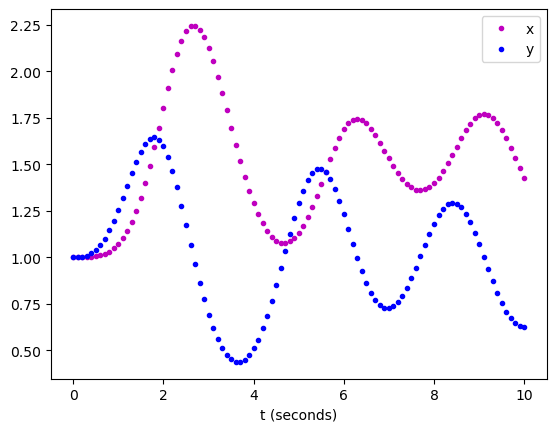

In [5]:
# define functions
def f(r,t):
    # r = np.array([x,y])
    x = r[0]
    y = r[1]

    # define actual differential equations
    fx = x*y - x
    fy = y - x*y + np.sin(omega*t)**2

    # return vector array of functions
    return np.array([fx,fy], float)

# define initial conditions $ constants
tstart = 0.0
tend = 10.0
N = 100
h = (tend-tstart) / N
omega = 1.0

tpts = np.arange(tstart, tend+h, h)

r = np.array([1,1], float)
xpts = np.zeros(len(tpts))
ypts = np.zeros(len(tpts))

# loop to apply fourt-order rune-kutta
for i in range(len(tpts)):
    xpts[i] = r[0]
    ypts[i] = r[1]
    k1 = h * f(r, tpts[i])
    k2 = h * f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h * f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h * f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

# make plot of results
plt.plot(tpts,xpts,".m")
plt.plot(tpts, ypts,".b")
plt.legend(["x","y"])
plt.xlabel("t (seconds)")

plt.show()


#### Exercise 8.2 - The Lotka-Volterra equations

Mathematical model of predator-prey interactions between biological species. Let two varaibles $x$ and $y$ be proportional to the size of the populations of two species, traditionally called “rabbits” (the prey) and “foxes” (the predators). You could think of $x$ and $y$ as being the population in thousands, say, so that $x = 2$ means there are 2000 rabbits. Strictly the only allowed values of $x$ and $y$ would then be multiples of 0.001, since you can only have whole numbers of rabbits or foxes. But 0.001 is a pretty close spacing of values, so it’s a decent approximation to treat $x$ and $y$ as continuous real numbers so long as neither gets very close to zero. This allows us to model the variation of the population sizes over time using differential equations. 

In the Lotka–Volterra model the rabbits reproduce at a rate proportional to their population, but are eaten by the foxes at a rate proportional to both their own population and the population of foxes:
$$ \frac{dx}{dt} = \alpha x - \beta xy$$
where $\alpha$ and $\beta$ are constants. At the same time the foxes reproduce at a rate proportional the rate at which they eat rabbits—because they need food to grow and reproduce—but also die of old age at a rate proportional to their own population:
$$\frac{dy}{dt} = \gamma xy - \delta y $$
where $\gamma$ and $\delta$ are also constants.

*a)* Write a program to solve these equations using the fourth-order Runge–Kutta method for the case $\alpha = 1, \beta = \gamma = 0.5,$ and $\delta = 2$, starting from the initial condition $x = y = 2$. Have the program make a graph showing both $x$ and $y$ as a function of time on the same axes from $t = 0$ to $t = 30$. (Hint: Notice that the differential equations in this case do not depend explicitly on time $t$—in vector notation, the right-hand side of each equation is a function $f(\bf{r})$ with no $t$ dependence. You may nonetheless find it convenient to define a Python function `f(r,t)` including the time variable, so that your program takes the same form as programs given earlier in this chapter. You don’t have to do it that way, but it can avoid some confusion. Several of the following exercises have a similar lack of explicit time-dependence.)

*b)* Describe in words what is going on in the system, in terms of rabbits and foxes.

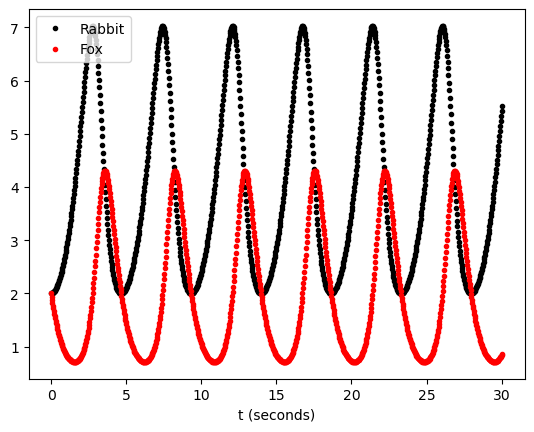

In [11]:
# define functions
def f(r,t):
    # r = np.array([x,y])
    x = r[0]
    y = r[1]

    # define actual differential equations
    fx = A*x - B*x*y # rabbit reproduction
    fy = C*x*y - D*y # fox reproduction

    # return vector array of functions
    return np.array([fx,fy], float)

# define initial conditions $ constants
tstart = 0.0
tend = 30.0
N = 1000
h = (tend-tstart) / N
A = 1
B = 0.5
C = 0.5
D = 2

tpts = np.arange(tstart, tend+h, h)

r = np.array([2,2], float) # starting position
xpts = np.zeros(len(tpts))
ypts = np.zeros(len(tpts))

# loop to apply fourt-order rune-kutta
for i in range(len(tpts)):
    xpts[i] = r[0]
    ypts[i] = r[1]
    k1 = h * f(r, tpts[i])
    k2 = h * f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h * f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h * f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

# make plot of results
plt.plot(tpts,xpts,".k") # rabbits
plt.plot(tpts, ypts,".r") # foxes
plt.legend(["Rabbit","Fox"])
plt.xlabel("t (seconds)")

plt.show()


## Second-order differential equations
#### Book example 8.6/Exercise 8.4: The nonlinear pendulum 

Unlike what you learned in introductory physics, a real pendulum is nonlinear. Consider a pendulum with an arm of length $\ell$ holding a bob of mass $m$. In terms fo the angle $\theta$ of displacement of the arm from the vertical, the accleration of the mass is $\ell d^2\theta/dt^2$ in the tangential direction. The force on the mass is vertically downward with magnitude $mg$, where $g=9.81$ m/s$^2$ is the acceleration due to gravity, and for the sake of simplicity, we are ignoring frictio and assuming the arm to be massless. The component of this force in the tangential direction if $mg \sin \theta$, always toward the rest point at $\theta = 0$, and hence Newton's second law gives us an equaton of motion for the pendulum of the form

$$ m\ell \frac{d^2\theta}{dt^2}=-mg\sin\theta$$

or equivalently 
$$ \frac{d^2\theta}{dt^2}=-\frac{g}{\ell}\sin\theta$$

Because it is nonlinear it is not easy to solve this equation anlytically, and no exact solution is known. But a solution on the computer is straightforward. We first use the trick we just learned

$$\frac{d\theta}{dt} = \omega $$

which then makes the original equation

$$\frac{d\omega}{dt} = -\frac{g}{\ell}\sin\theta $$

We have split up the single second-order DEQ into two first-order DEQs. Combine the two variables $\theta$ and $\omega$ into a single vector **r** $ =(\theta,\omega)$ and we can now apply fourth-order Runge-Kutta in vector form to solve. 

This will give solutions for both $\theta$ and $\omega$, and we can just ignore $\omega$ if we don't want it/need it. 

To fully analyze this problem, solve the two first-order equations using the fourth-order Runge–Kutta method for a pendulum with a 10 cm arm. Use your program to calculate the angle $\theta$ of displacement for several periods of the pendulum when it is released from a standstill at $\theta = 179^\circ$ from the vertical. Make a graph of $\theta$ as a function of time. 

In [ ]:
# define functions
def f(r,t):
    theta = r[0]
    omega = r[1]
    
    # define actual differential equations
    ftheta = omega
    fomega = -g/l * (np.sin(theta))

    # return vector array of functions
    return np.array([ftheta,fomega], float)

# define initial conditions $ constants
tstart = 0.0
tend = 10.0
N = 1000
h = (tend-tstart) / N

g = 9.81 # m/s^2
l = 0.1 # in centimeters

tpts = np.arange(tstart,tend+h, h)

r = np.array([np.radians(179), 0], float) # starting position
thetapts = np.zeros(len(tpts))
omegapts = np.zeros(len(tpts))

# loop to apply fourt-order rune-kutta
for i in range(len(tpts)):
    thetapts[i] = r[0]
    omegapts[i] = r[1]
    k1 = h * f(r, tpts[i])
    k2 = h * f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h * f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h * f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

# make plot of results
plt.plot(tpts,thetapts,".k") # rabbits
plt.plot(tpts, omegapts,".r") # foxes
plt.legend(["Theta","Omega"])
plt.xlabel("t (seconds)")

plt.show()


NameError: name 'np' is not defined